<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             Q-LEARNING PARAMETERS
Alpha (α)   : 0.8
Beta (β)    : 0.01
Gamma (γ)   : 0.95
Epsilon (ε) : 0.01
Episodes    : 1000

                    Q-TABLE

State		Left		Right
0		3.21		4.44
1		3.21		5.72
2		4.44		7.07
3		5.72		8.50
4		7.07		10.00
5		0.00		0.00

                    BEST PATH
0 -> 1 -> 2 -> 3 -> 4 -> 5


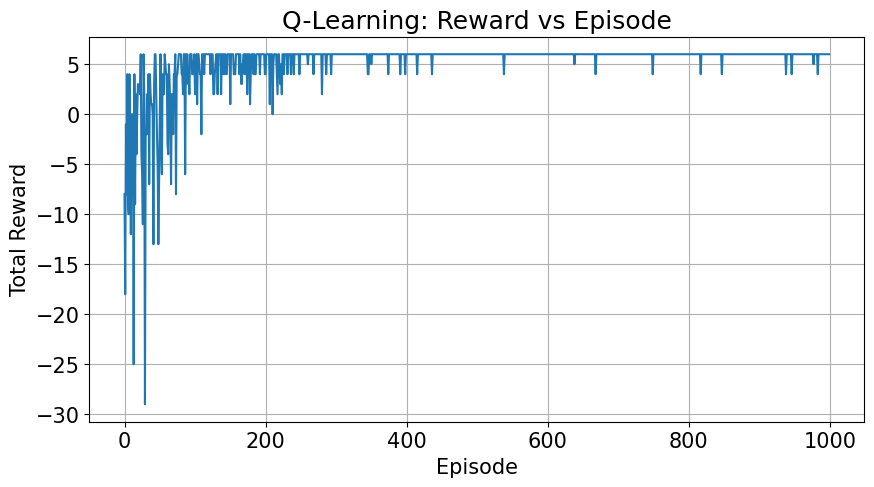

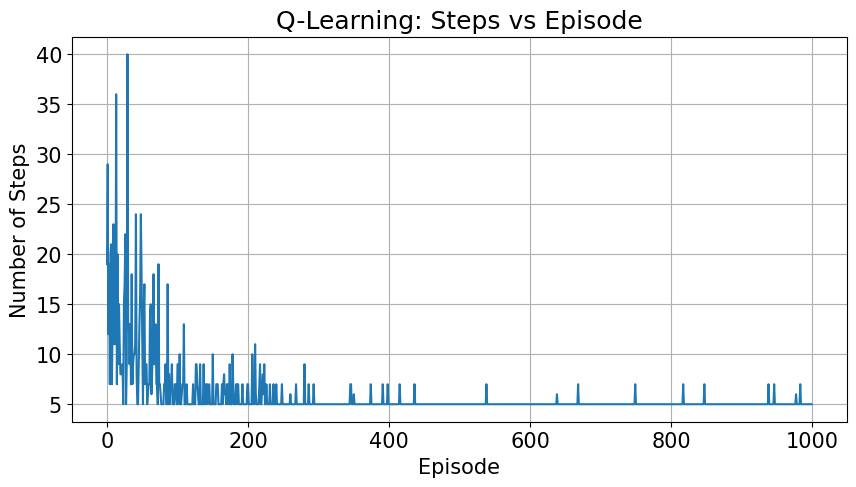

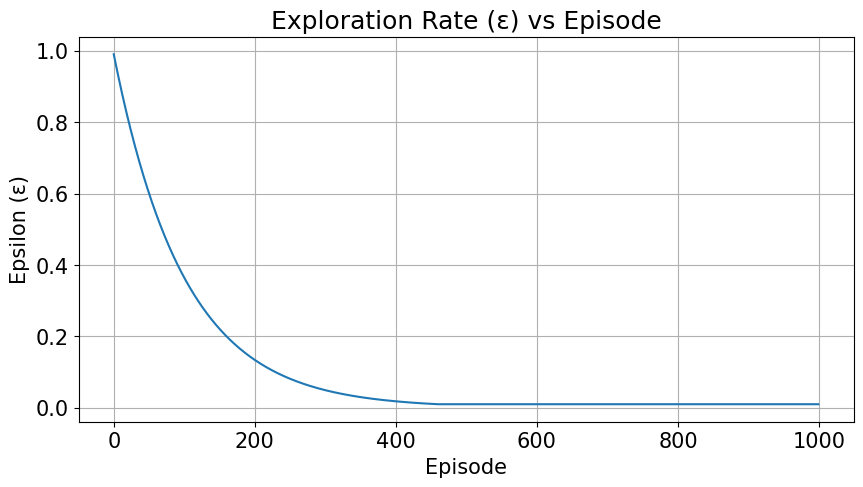

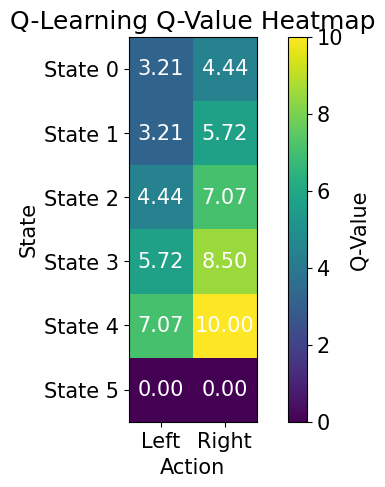


              TRAINING COMPLETED
Starting State : 0
Goal State     : 5
Best Path      : [0, 1, 2, 3, 4, 5]
Final Epsilon  : 0.01


In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================================
# REINFORCEMENT LEARNING - Q-LEARNING
# ============================================================

# -----------------------------
# Environment
# -----------------------------

NUM_STATES = 6
NUM_ACTIONS = 2
GOAL_STATE = 5

# Actions
LEFT = 0
RIGHT = 1


# ============================================================
# Q-LEARNING PARAMETERS
# ============================================================

alpha = 0.8       # α - Learning Rate
gamma = 0.95      # γ - Discount Factor
epsilon = 1.0     # ε - Initial Exploration Rate
beta = 0.01       # β - Exploration Decay Rate

min_epsilon = 0.01

episodes = 1000


# ============================================================
# CREATE Q-TABLE
# ============================================================

Q = np.zeros((NUM_STATES, NUM_ACTIONS))


# ============================================================
# STORE DATA FOR GRAPHS
# ============================================================

episode_rewards = []
episode_steps = []
epsilon_values = []


# ============================================================
# ENVIRONMENT
# ============================================================

def take_action(state, action):

    # Move Left
    if action == LEFT:
        next_state = max(0, state - 1)

    # Move Right
    else:
        next_state = min(NUM_STATES - 1, state + 1)

    # Reward
    if next_state == GOAL_STATE:
        reward = 10
    else:
        reward = -1

    return next_state, reward


# ============================================================
# TRAINING
# ============================================================

for episode in range(episodes):

    # Start from state 0
    state = 0

    total_reward = 0
    steps = 0

    while state != GOAL_STATE:

        # ----------------------------------------------------
        # EPSILON-GREEDY ACTION SELECTION
        # ----------------------------------------------------

        if random.random() < epsilon:

            # Exploration
            action = random.randint(0, NUM_ACTIONS - 1)

        else:

            # Exploitation
            action = np.argmax(Q[state])


        # ----------------------------------------------------
        # TAKE ACTION
        # ----------------------------------------------------

        next_state, reward = take_action(state, action)


        # ----------------------------------------------------
        # Q-LEARNING UPDATE
        # ----------------------------------------------------

        old_q = Q[state, action]

        best_next_q = np.max(Q[next_state])

        Q[state, action] = old_q + alpha * (
            reward
            + gamma * best_next_q
            - old_q
        )


        # ----------------------------------------------------
        # UPDATE STATE
        # ----------------------------------------------------

        state = next_state

        total_reward += reward
        steps += 1


        # Prevent infinite loop
        if steps >= 100:
            break


    # ========================================================
    # BETA - EXPLORATION DECAY
    # ========================================================

    epsilon = max(
        min_epsilon,
        epsilon * np.exp(-beta)
    )


    # Store results
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    epsilon_values.append(epsilon)


# ============================================================
# DISPLAY PARAMETERS
# ============================================================

print("=" * 60)
print("             Q-LEARNING PARAMETERS")
print("=" * 60)

print("Alpha (α)   :", alpha)
print("Beta (β)    :", beta)
print("Gamma (γ)   :", gamma)
print("Epsilon (ε) :", epsilon)
print("Episodes    :", episodes)


# ============================================================
# DISPLAY Q-TABLE
# ============================================================

print("\n" + "=" * 60)
print("                    Q-TABLE")
print("=" * 60)

print("\nState\t\tLeft\t\tRight")

for state in range(NUM_STATES):

    print(
        f"{state}\t\t"
        f"{Q[state, LEFT]:.2f}\t\t"
        f"{Q[state, RIGHT]:.2f}"
    )


# ============================================================
# FIND BEST PATH
# ============================================================

state = 0

path = [state]

while state != GOAL_STATE:

    action = np.argmax(Q[state])

    if action == LEFT:

        state = max(0, state - 1)

    else:

        state = min(NUM_STATES - 1, state + 1)

    path.append(state)


print("\n" + "=" * 60)
print("                    BEST PATH")
print("=" * 60)

print(" -> ".join(map(str, path)))


# ============================================================
# GRAPH 1
# REWARD VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(episode_rewards)

plt.title("Q-Learning: Reward vs Episode")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2
# STEPS VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(episode_steps)

plt.title("Q-Learning: Steps vs Episode")

plt.xlabel("Episode")

plt.ylabel("Number of Steps")

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 3
# EPSILON VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(epsilon_values)

plt.title("Exploration Rate (ε) vs Episode")

plt.xlabel("Episode")

plt.ylabel("Epsilon (ε)")

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 4
# Q-TABLE HEATMAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.imshow(Q, cmap="viridis")

plt.colorbar(label="Q-Value")

plt.xticks(
    [0, 1],
    ["Left", "Right"]
)

plt.yticks(
    range(NUM_STATES),
    [f"State {i}" for i in range(NUM_STATES)]
)

plt.xlabel("Action")

plt.ylabel("State")

plt.title("Q-Learning Q-Value Heatmap")


# Display Q-values
for i in range(NUM_STATES):

    for j in range(NUM_ACTIONS):

        plt.text(
            j,
            i,
            f"{Q[i, j]:.2f}",
            ha="center",
            va="center",
            color="white"
        )

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("              TRAINING COMPLETED")
print("=" * 60)

print("Starting State :", 0)

print("Goal State     :", GOAL_STATE)

print("Best Path      :", path)

print("Final Epsilon  :", round(epsilon, 4))